# California Housing Analysis 
Since the objective is to prioritize potentially high-value areas, minimizing false negatives is more important than minimizing false positives.  
Therefore, recall for the positive class is chosen as the primary evaluation metric.

After model evaluation and optimization with supervised training unsupervized training is used to find groups within the data.

**Tabel of Content**
- Load Data  
-- Feature Engineering  
-- Correlation Matrix  
-- Create Binary Target  
- EDA  
-- Load Data and EDA Summary
- Train / Test Split
- Evaluation Metrics Function  
- Preprocessing
- Baseline and Model Comparison (Cross-Validation)  
-- Model Comparison Summary
- Model Optimization  
-- Hyperparameter Tuning (GridSearchCV)  
-- Threshold Selection (OOF Predictions)  
-- Precision-Recall Curve (OOF)  
-- Model Optimization Summary  
- Final Test Evaluation  
--Test Evaluation Summary
- Unsupervised Learning  
- KMeans Clustering and Cluster Interpretation  
-- Kmeans Summary

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    average_precision_score,
)

sns.set_context("notebook")

## Load Data

In [ ]:
df = pd.read_csv("data/housing.csv")

df.head()

### Feature Engineering
As some features are raw totals more usefull infomation can be obtained from creating ratio features.   
- rooms_per_household - the average number of rooms per household, indicating the typical housing size in an area
- population_per_household - the average number of people per household, indicating the level of household crowding in an area

In [ ]:
df["rooms_per_household"] = df["total_rooms"] / df["households"].replace(0, np.nan)
df["population_per_household"] = df["population"] / df["households"].replace(0, np.nan)

X = df.drop(columns=["median_house_value"])

print(f"X rows:", X.shape[0], "X columns:", X.shape[1])

display(X.describe().T)

### Correlation Matrix

In [ ]:
df_for_eda = X.copy()

correlation_matrix = df_for_eda.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.title("Correlation Matrix")

### Create Binary Target

In [ ]:
# Binary y/target creation from top 20% of median_house_value
threshold = df["median_house_value"].quantile(0.80)
y = (df["median_house_value"] >= threshold).astype(int)
y = pd.Series(y, name="high_value")

# Naming classes (for humans)
target_names = np.array(["not_high_value", "high_value"])

## EDA

In [ ]:
counts = pd.Series(y).value_counts().sort_index()
display(pd.DataFrame({
    "target": counts.index,
    "number": counts.values,
    "share": (counts.values / counts.values.sum())
}))

display(X.describe().T)

missing_summary = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_percent": (X.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)

display(missing_summary)

X["total_bedrooms"].hist(bins=30, figsize=(8, 6))
plt.title("Histogram of total_bedrooms")
plt.xlabel("total_bedrooms")
plt.ylabel("Count")
plt.show()

X.select_dtypes(include="number").plot(kind="box", figsize=(8, 6))
plt.title("Boxplot of numerical features")
plt.xticks(rotation=45)
plt.show()

### Load Data and EDA Summary

The dataset contains 20,640 observations describing housing areas in California, with both numerical and categorical variables such as geographic location, household characteristics and income.

Feature engineering was performed directly after loading data as some features are raw totals and more usefull information can be obtained from creating ratio features such as:     
- rooms_per_household - the average number of rooms per household, indicating the typical housing size in an area  
- population_per_household - the average number of people per household, indicating the level of household crowding in an area  

The correlation matrix shows strong correlations among aggregated totals such as total_rooms, total_bedrooms, population and households. These variables largely reflect the size of an area. The engineered ratio features (rooms_per_household and population_per_household) show weaker correlations with the totals, suggesting that they capture additional structural information.

A binary target variable (high_value) was created from median_house_value, where values in the top 20% are labeled as 1 and the rest as 0.

The EDA confirmed that the binary target was defined using the 80th percentile of median house values, resulting in an approximate 80/20 class distribution.

The feature total_bedrooms contains approximately 1% missing values. Given the skewed distribution and presence of outliers, median imputation is considered more robust than mean imputation.

Several numerical features exhibit strong right-skewness and substantial variation in scale, particularly aggregated totals such as total_rooms and population. Since distance-based and linear models are sensitive to feature scale, standardization is required to prevent features with large magnitudes from dominating the learning process. Tree-based models are less sensitive to scaling, which is considered in the model comparison.

## Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Evaluation Metrics Function

In [ ]:
def evaluate_classification(y_true, y_pred) -> dict:
   
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

## Preprocessing

In [ ]:
numeric_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(exclude="number").columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

## Baseline and Model Comparison (Cross-Validation)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "recall"

models = {}

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(
        strategy="most_frequent",
        random_state=42))
])
models["Baseline"] = baseline

logreg = Pipeline(steps=[
    ("preprocess", preprocess), 
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42))
])
models["LogReg"] = logreg

knn = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier())
])
models["KNN"] = knn

tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=3))
])
models["Tree"] = tree

ranfor = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1))
])
models["Random Forest"] = ranfor

rows = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1
    )
    rows.append({
        "model": name,
        f"cv_mean_{SCORING}": scores.mean(),
        f"cv_std_{SCORING}": scores.std()
    })

results_cv = pd.DataFrame(rows).sort_values(f"cv_mean_{SCORING}", ascending=False).round(6)
results_cv

### Model Comparison Summary

The cross-validation results show that Random Forest achieves the highest recall (0.72) among the evaluated models. Recall was prioritized because the objective is to identify as many high-value areas as possible. In this case, missing a truly high-value area (false negative) is considered more problematic than flagging some extra areas for further review (false positives). Therefore, Random Forest was selected for further tuning.

The model also showed relatively low variation across folds, suggesting stable performance during cross-validation.

## Model Optimization

### Hyperparameter Tuning (GridSearchCV)

In [ ]:
chosen_model_name = "Random Forest"
print ("Tuning:", chosen_model_name)

param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=models[chosen_model_name],
    param_grid=param_grid,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1
)

grid.fit(X_train, y_train)

cv_results = pd.DataFrame(grid.cv_results_)
best_row = cv_results.loc[grid.best_index_]

best_summary = pd.DataFrame(
    {**grid.best_params_,
    f"cv_mean_{SCORING}": best_row["mean_test_score"],
    f"cv_std_{SCORING}": best_row["std_test_score"]},
    index=["Best Random Forest (CV)"]
)

display(best_summary.round(6))

best_model = grid.best_estimator_

### Threshold Selection (OOF Predictions)

In [ ]:
oof_proba = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)

rows = []

for t in thresholds:
    preds = (oof_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_train, preds, zero_division=0),
        "recall": recall_score(y_train, preds, zero_division=0),
        "f1": f1_score(y_train, preds, zero_division=0)
    })

thr_df = pd.DataFrame(rows)

best_row = thr_df.sort_values(["f1", "threshold"], ascending=[False, False]).iloc[0]
best_t = float(best_row["threshold"])

print("Best threshold (OOF, max F1):", round(best_t, 4))
display(best_row.to_frame().T.round(4))

### Precision-Recall Curve (OOF)

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_train, oof_proba)

ap = average_precision_score(y_train, oof_proba)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curve (OOF, AP = {ap:.3f})")
plt.show()

### Model Optimization Summary
Hyperparameter tuning of the Random Forest model resulted in only a marginal improvement in cross-validated recall compared to the initial configuration. This is expected, as Random Forest models are generally robust and relatively insensitive to moderate hyperparameter changes. The tuning step therefore mainly confirms that the selected parameter range produces a stable and well-performing model rather than substantially improving predictive performance.

While recall was used as the primary metric during model comparison, the threshold selection step optimizes the F1-score instead. This is because recall alone can be increased simply by lowering the classification threshold, which may lead to an excessive number of false positives. The F1-score balances precision and recall, ensuring that improved recall does not come at the cost of an unacceptable drop in precision.

To avoid data leakage, the optimal threshold was determined using out-of-fold (OOF) predictions generated via cross-validation on the training data. The selected threshold (0.41) improved recall compared to the default threshold of 0.50 while maintaining good precision, resulting in a higher overall F1-score.

## Final Test Evaluation

In [ ]:
best_model.fit(X_train, y_train)

rows = []

baseline.fit(X_train, y_train)
y_pred_dummy = baseline.predict(X_test)
rows.append({
    "model": "Dummy (most_frequent)",
    **evaluate_classification(y_test, y_pred_dummy)
})

y_pred_rf_default = best_model.predict(X_test)
rows.append({
    "model": "Random Forest (thr=0.50)",
    **evaluate_classification(y_test, y_pred_rf_default)
})

proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_rf_thr = (proba_test >= best_t).astype(int)

rows.append({
    "model": f"Random Forest (thr={best_t:.2f})",
    **evaluate_classification(y_test, y_pred_rf_thr)
})

comparison_df = (
    pd.DataFrame(rows)
      .set_index("model")
      .round(4)
)

display(comparison_df)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_thr)
plt.title(f"Best Model Confusion Matrix from (test, thr={best_t:.2f}))")
plt.show()

### Test Evaluation Summary
The final evaluation on the test set confirms that the model generalizes well, with performance close to the cross-validation estimates.

## Unsupervised Learning – KMeans Clustering and Cluster Interpretation

In [44]:
X_train_cluster = X_train.copy()
X_test_cluster = X_test.copy()

ratio_cols = ["rooms_per_household", "population_per_household"]

for col in ratio_cols:
    if col in X_train_cluster.columns:
        X_train_cluster[col] = pd.to_numeric(X_train_cluster[col], errors="coerce")
    if col in X_test_cluster.columns:
        X_test_cluster[col] = pd.to_numeric(X_test_cluster[col], errors="coerce")

X_train_num = X_train_cluster.select_dtypes(include=["number"]).copy()
X_test_num = X_test_cluster.select_dtypes(include=["number"]).copy()

common_numeric_cols = X_train_num.columns.intersection(X_test_num.columns)
X_train_num = X_train_num[common_numeric_cols]
X_test_num = X_test_num[common_numeric_cols]

cluster_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_scaled = cluster_preprocess.fit_transform(X_train_num)
X_test_scaled = cluster_preprocess.transform(X_test_num)

In [45]:
K_MIN, K_MAX = 2, 8
rows = []

for k in range(K_MIN, K_MAX + 1):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_train_scaled)

    rows.append({
        "K": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_train_scaled, labels_k)
    })

scores = pd.DataFrame(rows)
display(scores.round(4))

,K,inertia,silhouette
0,2,130201.6606,0.4089
1,3,104591.5694,0.2988
2,4,90042.5170,0.3000
3,5,79810.2592,0.2944
4,6,71862.7289,0.2876
5,7,65370.6941,0.2788
6,8,60088.0083,0.2508


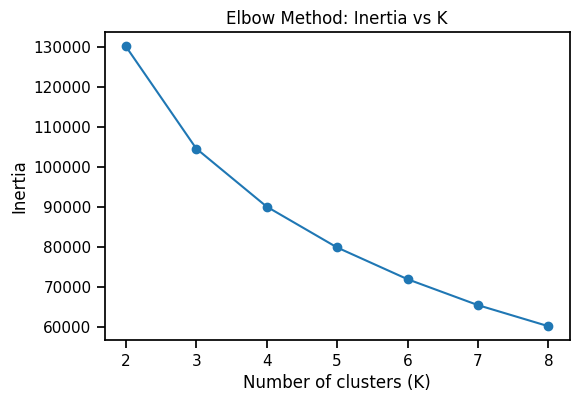

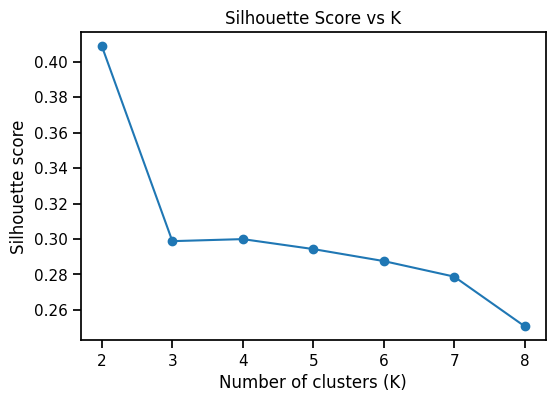

In [46]:
# Elbow plot
plt.figure(figsize=(6, 4))
plt.plot(scores["K"], scores["inertia"], marker="o")
plt.title("Elbow Method: Inertia vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Silhouette plot
plt.figure(figsize=(6, 4))
plt.plot(scores["K"], scores["silhouette"], marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.show()

In [47]:
K_final = 2

kmeans_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
train_clusters = kmeans_final.fit_predict(X_train_scaled)
test_clusters = kmeans_final.predict(X_test_scaled)

print("Cluster sizes in training data:")
print(pd.Series(train_clusters).value_counts().sort_index())

Cluster sizes in training data:
0    14596
1     1916
Name: count, dtype: int64


In [48]:
X_train_raw_profile = X_train_num.copy()
X_train_raw_profile["cluster"] = train_clusters

X_train_z_profile = pd.DataFrame(X_train_scaled, columns=common_numeric_cols, index=X_train_num.index)
X_train_z_profile["cluster"] = train_clusters

cluster_sizes = (
    X_train_raw_profile["cluster"]
    .value_counts()
    .sort_index()
    .rename("n_areas")
)

print("Cluster profiles (median values, original scale)")
profiles_raw = (
    X_train_raw_profile
    .groupby("cluster")
    .median(numeric_only=True)
    .join(cluster_sizes)
)
display(profiles_raw.round(3))

print("Cluster profiles (median values, standardized scale)")
profiles_z = (
    X_train_z_profile
    .groupby("cluster")
    .median(numeric_only=True)
    .join(cluster_sizes)
)
display(profiles_z.round(3))

Cluster profiles (median values, original scale)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,n_areas
cluster,,,,,,,,,,,
0,-118.59,34.28,31.0,1953.0,399.0,1066.0,376.0,3.50,5.219,2.822,14596
1,-118.38,34.17,17.0,5818.0,1190.5,3012.0,1096.0,3.85,5.354,2.800,1916


Cluster profiles (median values, standardized scale)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household,n_areas
cluster,,,,,,,,,,,
0,0.496,-0.639,0.185,-0.312,-0.319,-0.311,-0.320,-0.195,-0.089,-0.032,14596
1,0.600,-0.690,-0.929,1.482,1.571,1.404,1.579,-0.010,-0.031,-0.035,1916


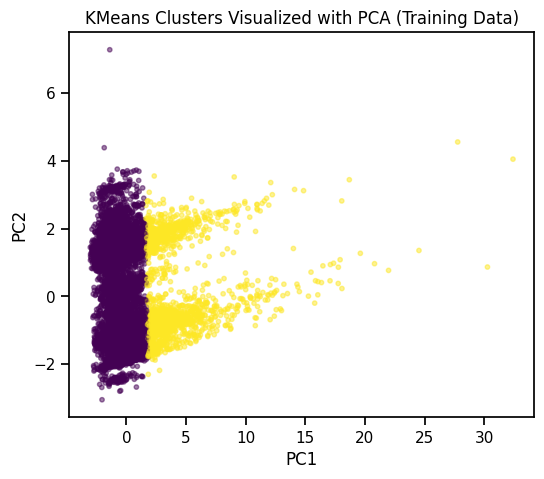

In [49]:
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=train_clusters,
    s=10,
    alpha=0.5
)
plt.title("KMeans Clusters Visualized with PCA (Training Data)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [50]:
train_cluster_df = X_train.copy()
train_cluster_df["cluster"] = train_clusters

if "ocean_proximity" in train_cluster_df.columns:
    print("Cluster vs Ocean Proximity (within-cluster proportions)")
    ocean_summary = pd.crosstab(
        train_cluster_df["cluster"],
        train_cluster_df["ocean_proximity"],
        normalize="index"
    ).round(2)
    display(ocean_summary)

Cluster vs Ocean Proximity (within-cluster proportions)


ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
cluster,,,,,
0,0.44,0.32,0.0,0.11,0.13
1,0.48,0.33,0.0,0.08,0.11


In [51]:
test_cluster_eval = pd.DataFrame({
    "cluster": test_clusters,
    "high_value": y_test
}, index=X_test.index)

print("Proportion of high-value areas within each cluster (test set)")
cluster_target_summary = pd.crosstab(
    test_cluster_eval["cluster"],
    test_cluster_eval["high_value"],
    normalize="index"
).round(3)
display(cluster_target_summary)

Proportion of high-value areas within each cluster (test set)


high_value,0,1
cluster,,
0,0.800,0.200
1,0.799,0.201


### Kmeans Summary

KMeans clustering was performed using only the feature matrix, excluding the target variable, to preserve the unsupervised nature of the analysis. To maintain methodological consistency with the classification task, preprocessing and clustering were fitted on the training set and then applied to the test set.

KMeans with K=2 revealed a dominant cluster representing typical residential areas and a smaller cluster characterized by significantly larger housing developments.

The smaller cluster shows substantially higher values for total rooms, bedrooms, households, and population, indicating denser and larger-scale residential zones. These areas also tend to have newer housing stock, as reflected by a lower median housing age.

Median income and household composition remain relatively similar across clusters, suggesting that socioeconomic factors are not the primary drivers of the segmentation.

Further analysis of ocean proximity shows nearly identical distributions between clusters, indicating that geographic coastal location does not explain the clustering structure. Instead, the main separation captured by KMeans appears to reflect differences in housing density and scale of development.

The PCA visualization confirms this interpretation, showing that the second cluster consists of observations located further along the principal component associated with housing scale variables.

The comparison with the binary target on the test set shows that the proportion of high-value areas is similar across clusters, suggesting that the clustering captures structural differences in housing characteristics rather than factors strongly associated with housing value.  